# FZP Cascade vs Optimized Cascade

This notebook compares three hard-X-ray focusing optics with the same number of elements, aperture, and aspect ratio (thickness / minimum feature size = 8):

- an **optimized diffractive cascade**
- an **intermediate-field cascade of Fresnel zone plates** whose focal lengths coincide at the target plane: the upstream plate fills the cascade aperture and downstream radii follow the first-order cone
- a **single Fresnel zone plate** at the last-element focal length (the paper baseline)

Load results produced by `paper/experiments/fzp_cascade_comparison.py`.

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

In [97]:
import sys
from pathlib import Path

repo_root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(repo_root))

In [98]:
matplotlib.rcParams['figure.dpi'] = 200
matplotlib.rcParams.update({'font.size': 24})

## Load comparison results

Prefer the stable untimestamped files written for this notebook. If those are missing, fall back to the latest timestamped run in `paper_data/`.

In [99]:
path = repo_root / "paper_data"
prefix = "fzp_cascade_comparison"
params_path = path / f"{prefix}_params.npy"
results_path = path / f"{prefix}_results.npz"

if not params_path.exists() or not results_path.exists():
    param_candidates = sorted(path.glob(f"{prefix}_params_*.npy"))
    if not param_candidates:
        raise FileNotFoundError(
            f"No {prefix} results in {path}. Run paper/experiments/fzp_cascade_comparison.py first."
        )
    params_path = param_candidates[-1]
    results_path = path / params_path.name.replace("_params_", "_results_").replace(".npy", ".npz")

params = np.load(params_path, allow_pickle=True).item()
results = np.load(results_path, allow_pickle=True)
print(params_path.name)
print(results_path.name)

Nx = int(params["Nx"])
dx = float(params["dx"])
Nelem = int(params["Nelem"])
r_max = float(params["r_max"])
n_half = Nx // 2
x = np.linspace(-Nx / 2, Nx / 2, Nx) * dx
r_half = np.abs(x[:n_half])

opt_rho = np.asarray(results["rho_bar"]).astype(float).reshape(-1)[: Nelem * n_half]
fzp_cascade_rho = np.asarray(results["fzp_cascade_rhos"]).astype(float).reshape(-1)[: Nelem * n_half]
opt_profiles = opt_rho.reshape(Nelem, n_half)
fzp_profiles = fzp_cascade_rho.reshape(Nelem, n_half)

labels = ["optimized cascade", "FZP cascade", "single FZP"]
efficiencies = np.array([
    float(results["opt_efficiency"]),
    float(results["fzp_cascade_efficiency"]),
    float(results["fzp_efficiency"]),
])
widths_um = np.array([
    float(results["opt_width"]),
    float(results["fzp_cascade_width"]),
    float(results["fzp_width"]),
]) * dx * 1e6
gains = np.array([
    float(results["opt_gain"]),
    float(results["fzp_cascade_gain"]),
    float(results["fzp_gain"]),
])
colors = ["C0", "C1", (0.4, 0.651, 0.118)]

fzp_cascade_comparison_params.npy
fzp_cascade_comparison_results.npz


## Focusing metrics

Efficiency, focal-spot width, and focusing gain for the three optics. Widths from the saved pixel radii are converted to microns with the simulation grid spacing.

N = 5, AR = 8, E = 10 keV
optic                    efficiency   width [um]         gain
optimized cascade            0.3048       0.0800  53587329.54
FZP cascade                  0.2831       0.0600 103954773.09
single FZP                   0.0272       0.0500  15452693.67


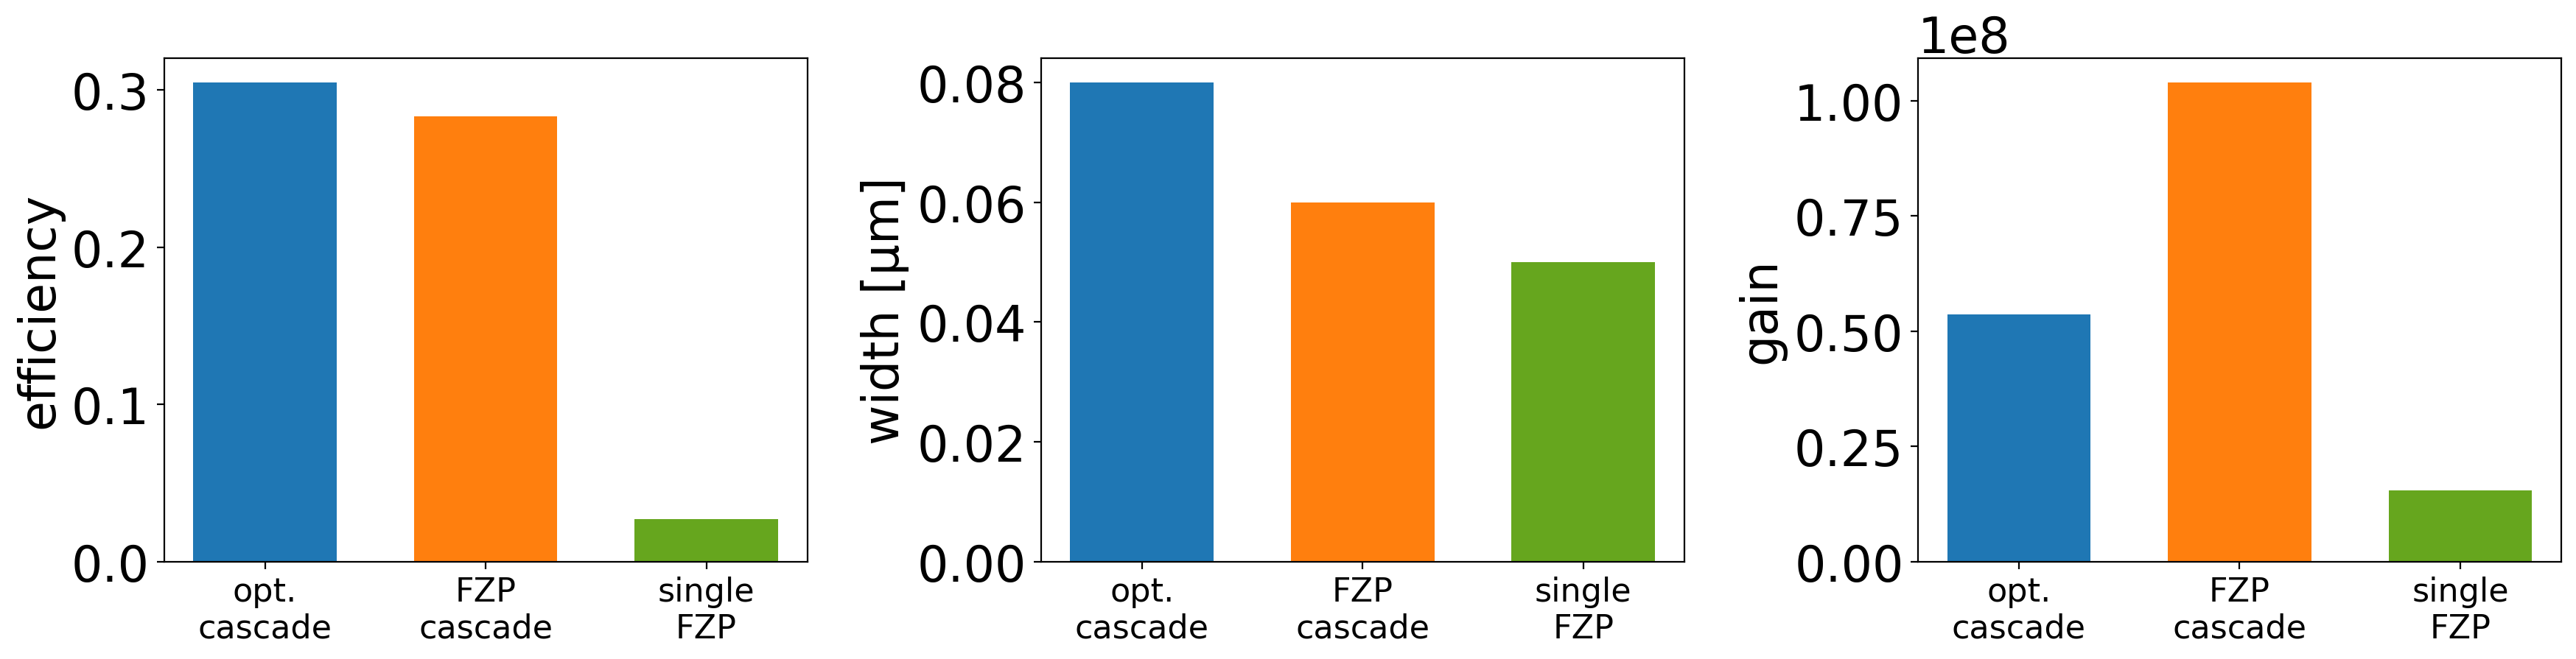

In [100]:
print(f"N = {Nelem}, AR = {params['aspect_ratio']:.0f}, E = {params['central_energy_ev']/1e3:.0f} keV")
print(f"{'optic':<22} {'efficiency':>12} {'width [um]':>12} {'gain':>12}")
for label, eff, width, gain in zip(labels, efficiencies, widths_um, gains):
    print(f"{label:<22} {eff:12.4f} {width:12.4f} {gain:12.2f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [efficiencies, widths_um, gains]
ylabels = ["efficiency", "width [µm]", "gain"]
for ax, values, ylabel in zip(axes, metrics, ylabels):
    ax.bar(np.arange(3), values, color=colors, width=0.65)
    ax.set_xticks(np.arange(3))
    ax.set_xticklabels(["opt.\ncascade", "FZP\ncascade", "single\nFZP"], fontsize=16)
    ax.set_ylabel(ylabel)
fig.tight_layout()

## Focal-plane lineouts

On-axis intensity along a diameter through the focal plane. The horizontal axis is cropped to a few microns around the optical axis.

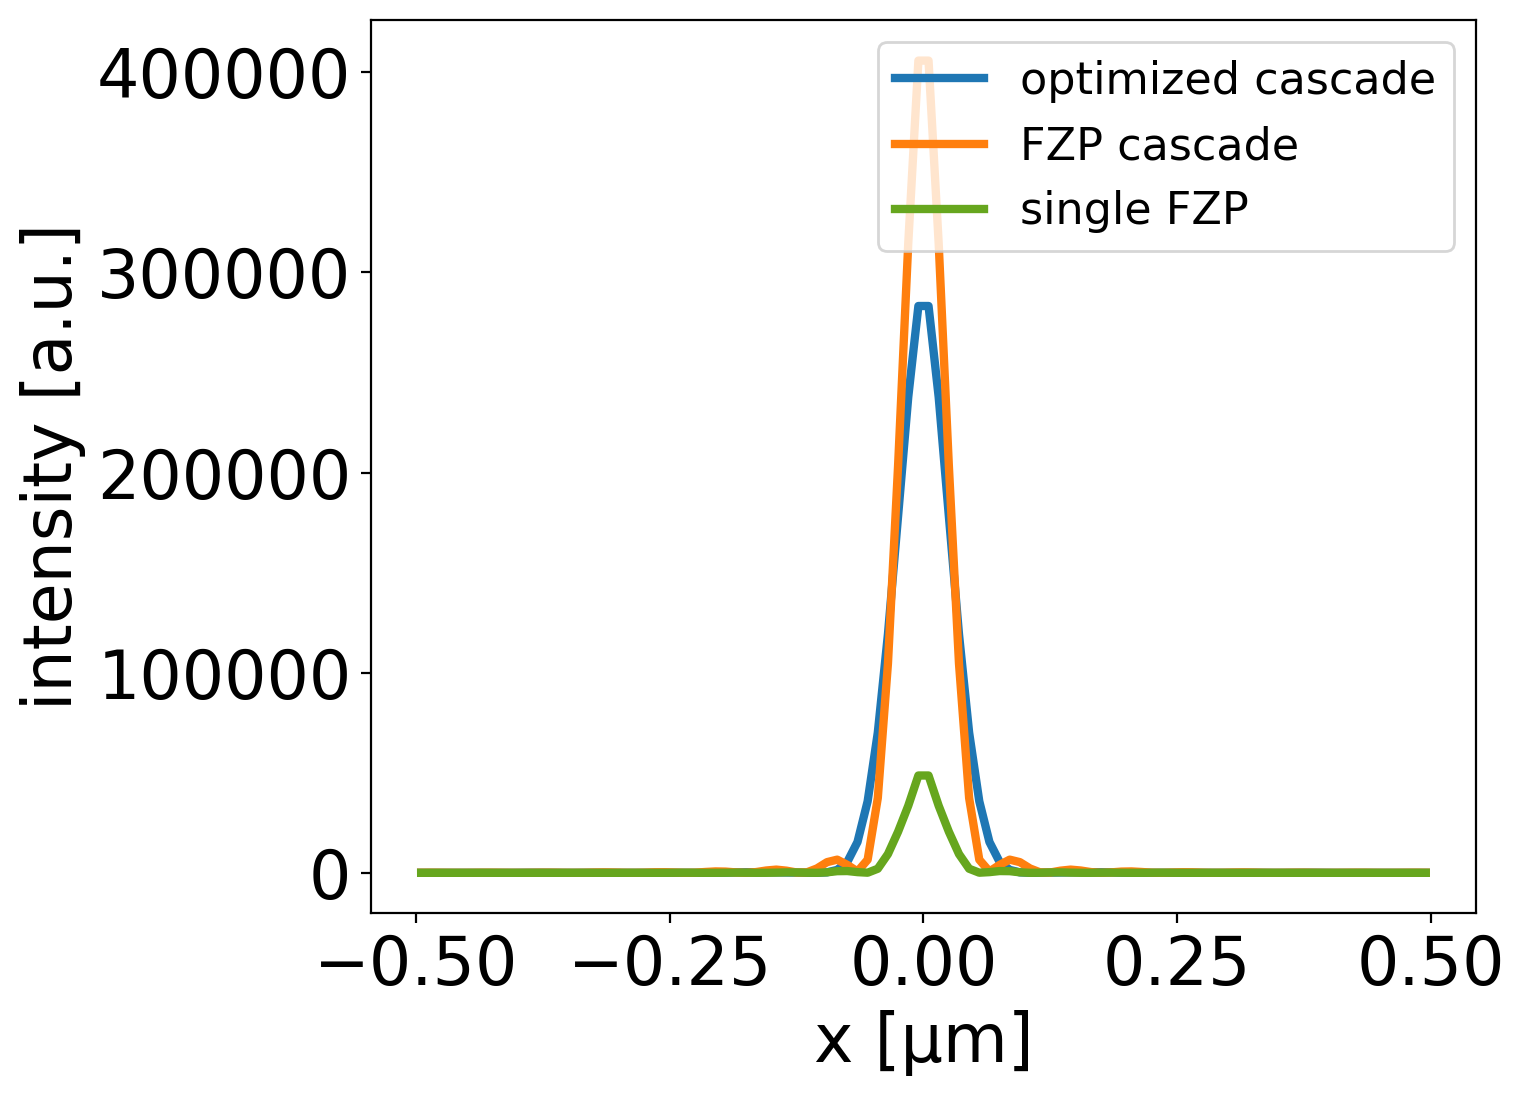

In [101]:
opt_I = np.asarray(results["opt_intensity"], dtype=float).reshape(-1)
fzp_cascade_I = np.asarray(results["fzp_cascade_intensity"], dtype=float).reshape(-1)
fzp_I = np.asarray(results["fzp_intensity"], dtype=float).reshape(-1)
n_I = opt_I.shape[0]
x_I = np.linspace(-n_I / 2, n_I / 2, n_I) * dx

x_lim_um = 0.5
mask_plot = np.abs(x_I) <= x_lim_um * 1e-6

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x_I[mask_plot] * 1e6, opt_I[mask_plot], linewidth=3, color=colors[0], label="optimized cascade")
ax.plot(x_I[mask_plot] * 1e6, fzp_cascade_I[mask_plot], linewidth=3, color=colors[1], label="FZP cascade")
ax.plot(x_I[mask_plot] * 1e6, fzp_I[mask_plot], linewidth=3, color=colors[2], label="single FZP")
ax.set_xlabel("x [µm]")
ax.set_ylabel("intensity [a.u.]")
ax.legend(fontsize=16)
fig.tight_layout()

## Radial element profiles

Binary half-profiles of each plate, plotted from the optical axis to the cascade aperture. The FZP cascade uses a longer focal length (hence coarser zones) for earlier plates, with the outer radius clipped at \(R_{\max}\).

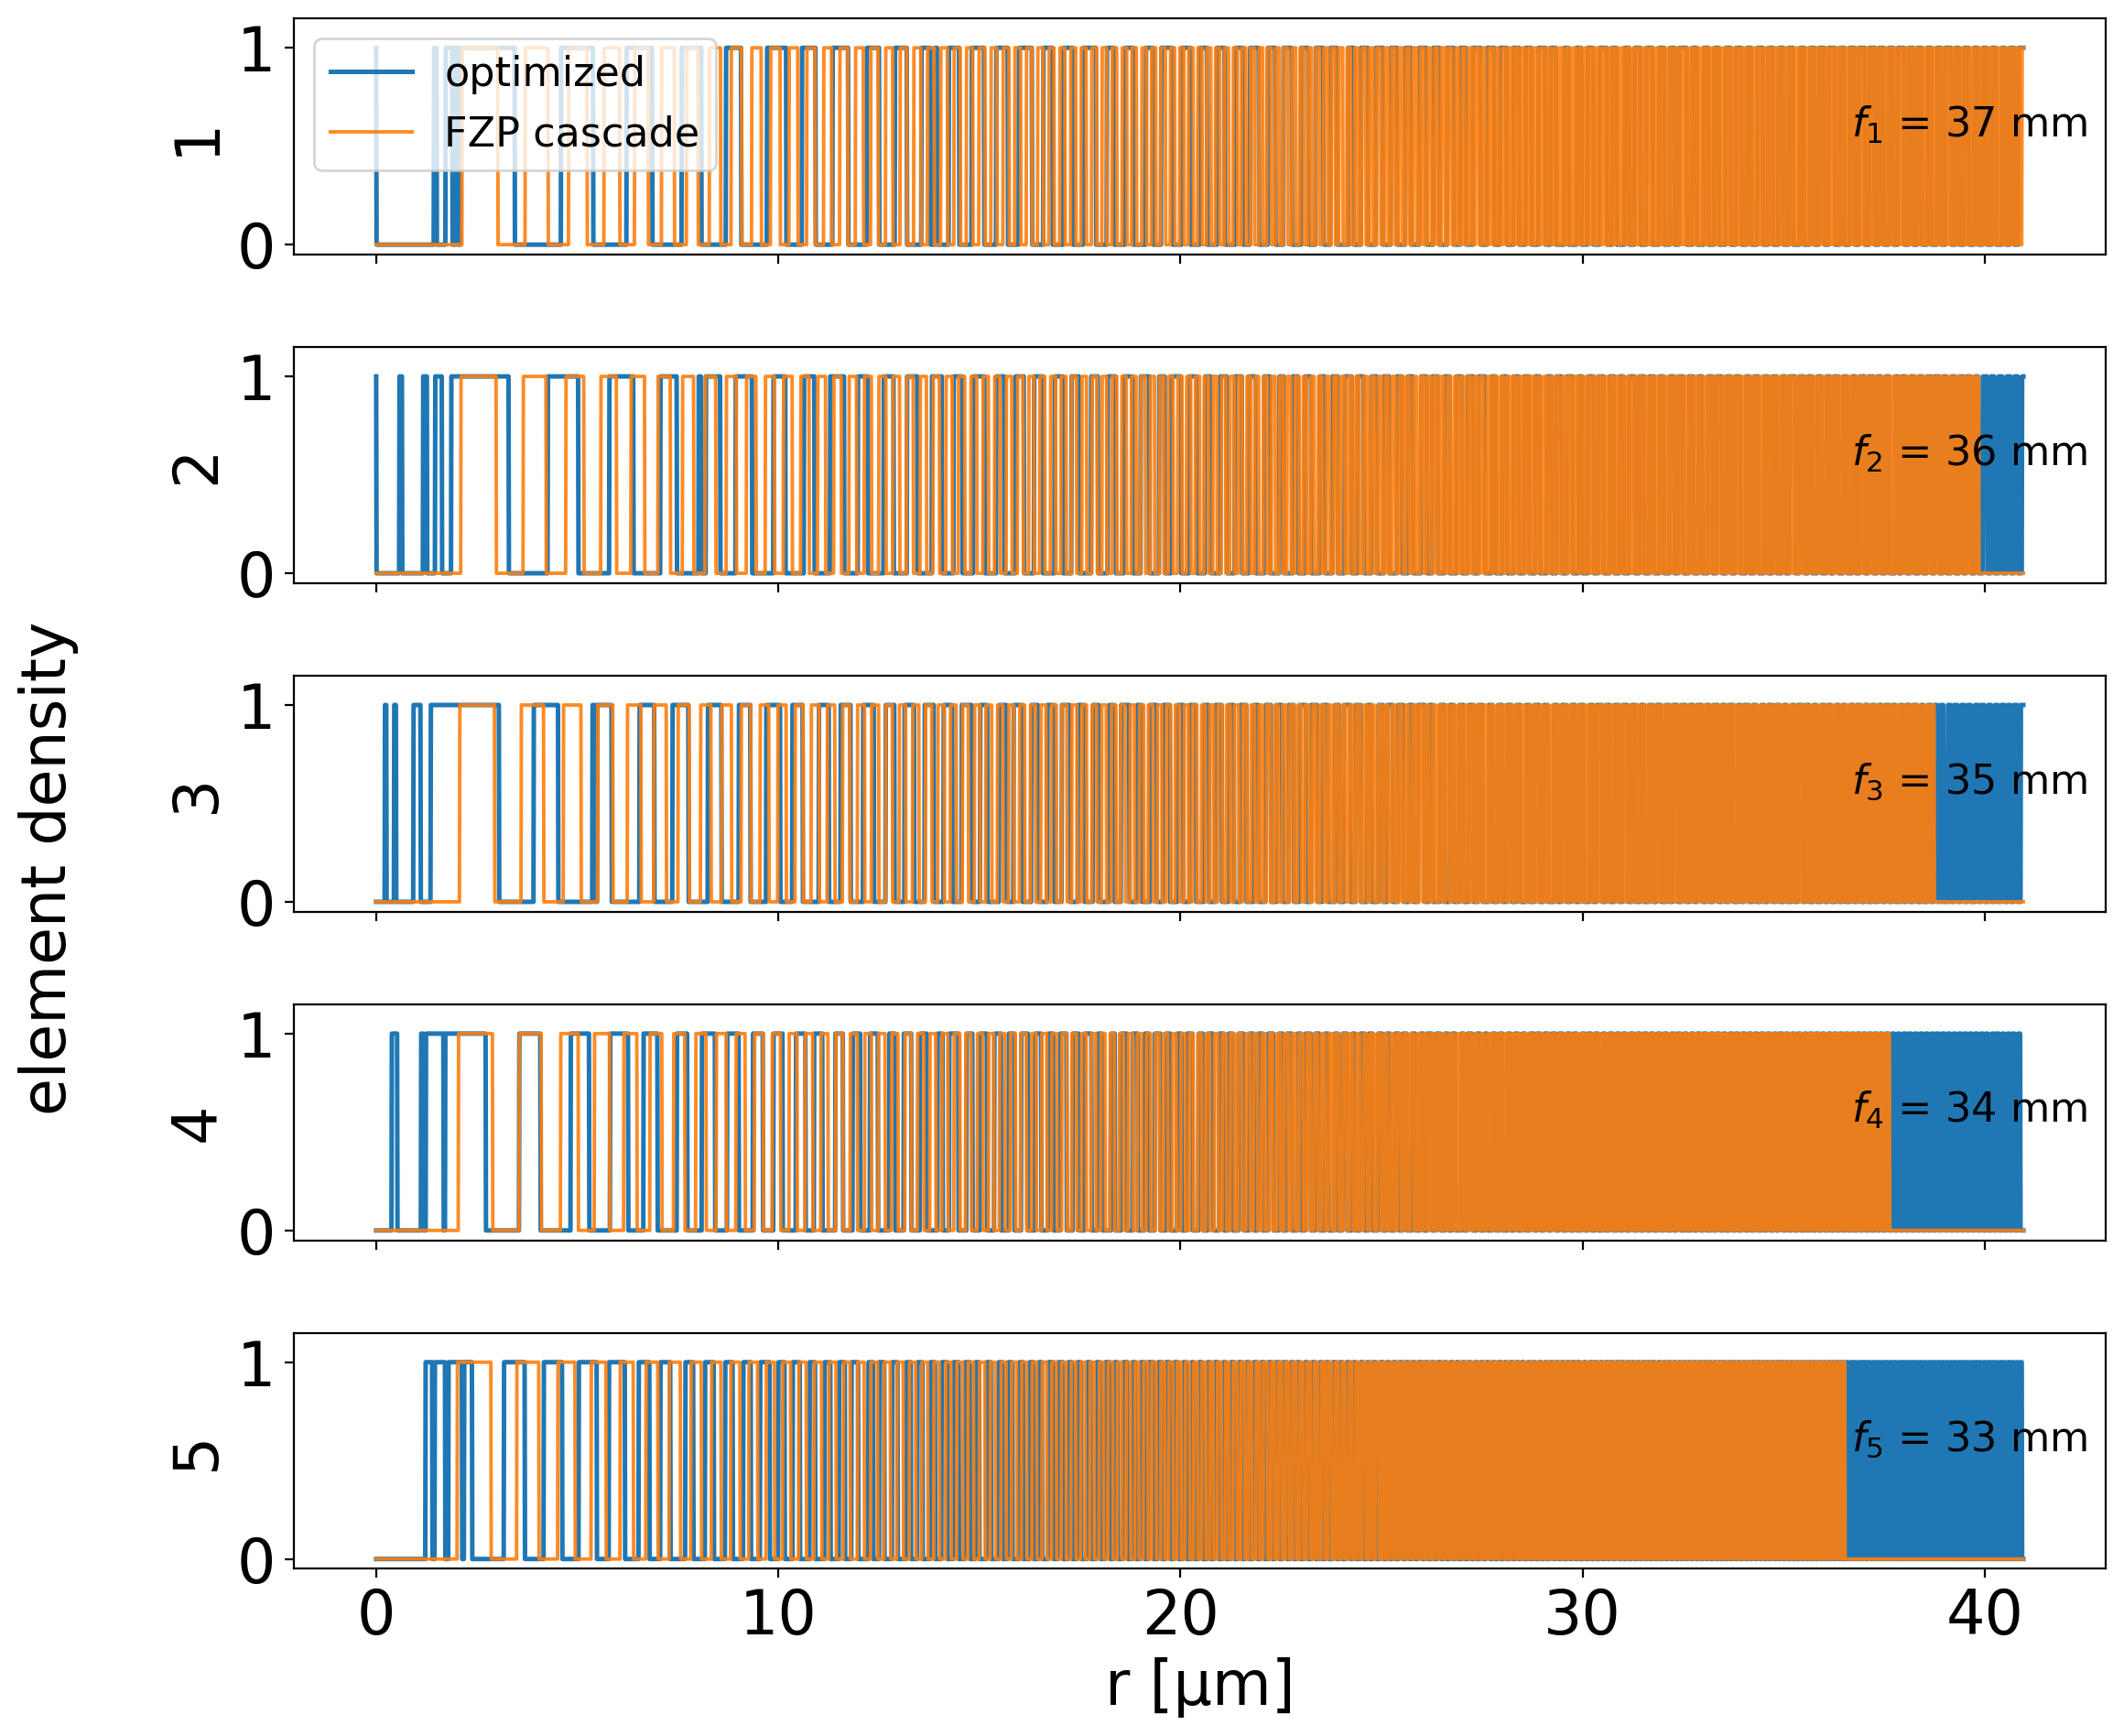

In [102]:
r_um = r_half[::-1] * 1e6
fig, axes = plt.subplots(Nelem, 1, figsize=(12, 2.0 * Nelem), sharex=True)
if Nelem == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.plot(r_um, opt_profiles[i, ::-1], color=colors[0], linewidth=1.8, label="optimized" if i == 0 else None)
    ax.plot(r_um, fzp_profiles[i, ::-1], color=colors[1], linewidth=1.4, alpha=0.9, label="FZP cascade" if i == 0 else None)
    ax.set_ylim(-0.05, 1.15)
    ax.set_yticks([0, 1])
    ax.set_ylabel(f"{i + 1}")
    f_i = float(results["fzp_focal_lengths"][i])
    ax.text(0.99, 0.55, f"$f_{{{i + 1}}}$ = {f_i * 1e3:.0f} mm", transform=ax.transAxes, ha="right", va="center", fontsize=16)
axes[0].legend(fontsize=16, loc="upper left")
axes[-1].set_xlabel("r [µm]")
fig.supylabel("element density", fontsize=24)
fig.tight_layout()

## Zone-plate radii

Unconstrained FZP radius \(R = \lambda f_i / (2\Delta r_{\min})\) versus the radius actually used after clipping to the cascade aperture \(R_{\max}\). Earlier plates (longer \(f_i\)) hit the cap.

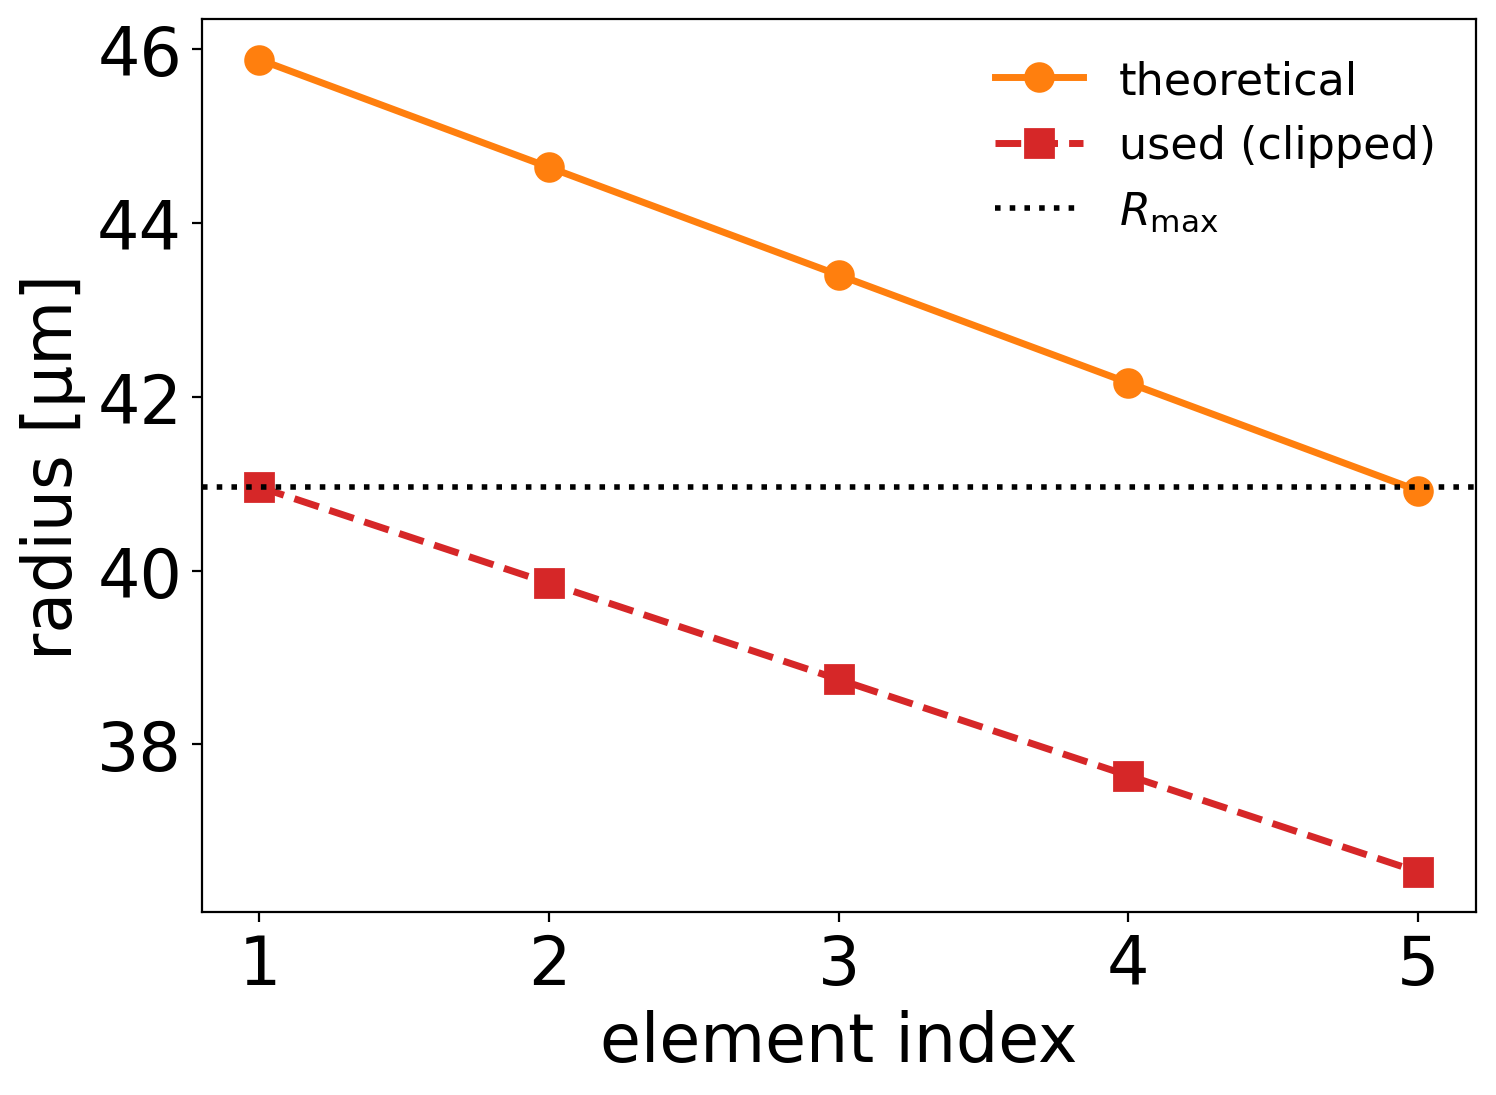

In [103]:
elem_idx = np.arange(1, Nelem + 1)
radii_theory = np.asarray(results["fzp_radii_theory"], dtype=float) * 1e6
radii_used = np.asarray(results["fzp_radii_used"], dtype=float) * 1e6

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(elem_idx, radii_theory, "o-", linewidth=2.5, markersize=10, color=colors[1], label="theoretical")
ax.plot(elem_idx, radii_used, "s--", linewidth=2.5, markersize=10, color="C3", label="used (clipped)")
ax.axhline(r_max * 1e6, color="k", linestyle=":", linewidth=2, label=r"$R_{\max}$")
ax.set_xlabel("element index")
ax.set_ylabel("radius [µm]")
ax.set_xticks(elem_idx)
ax.legend(fontsize=16, frameon=False)
fig.tight_layout()

## Feature-size distributions

Interior run lengths of the binary radial profiles, converted to nanometers. For each cascade, features from all \(N\) plates are pooled into one distribution. The first and last run of each plate (outer aperture and central zone) are omitted.


optic                         N   min [nm]  median [nm]   max [nm]
optimized cascade          1412       40.0        110.0     1700.0
FZP cascade                1724       50.0         80.0      890.0
single FZP                  408       50.0         70.0      840.0


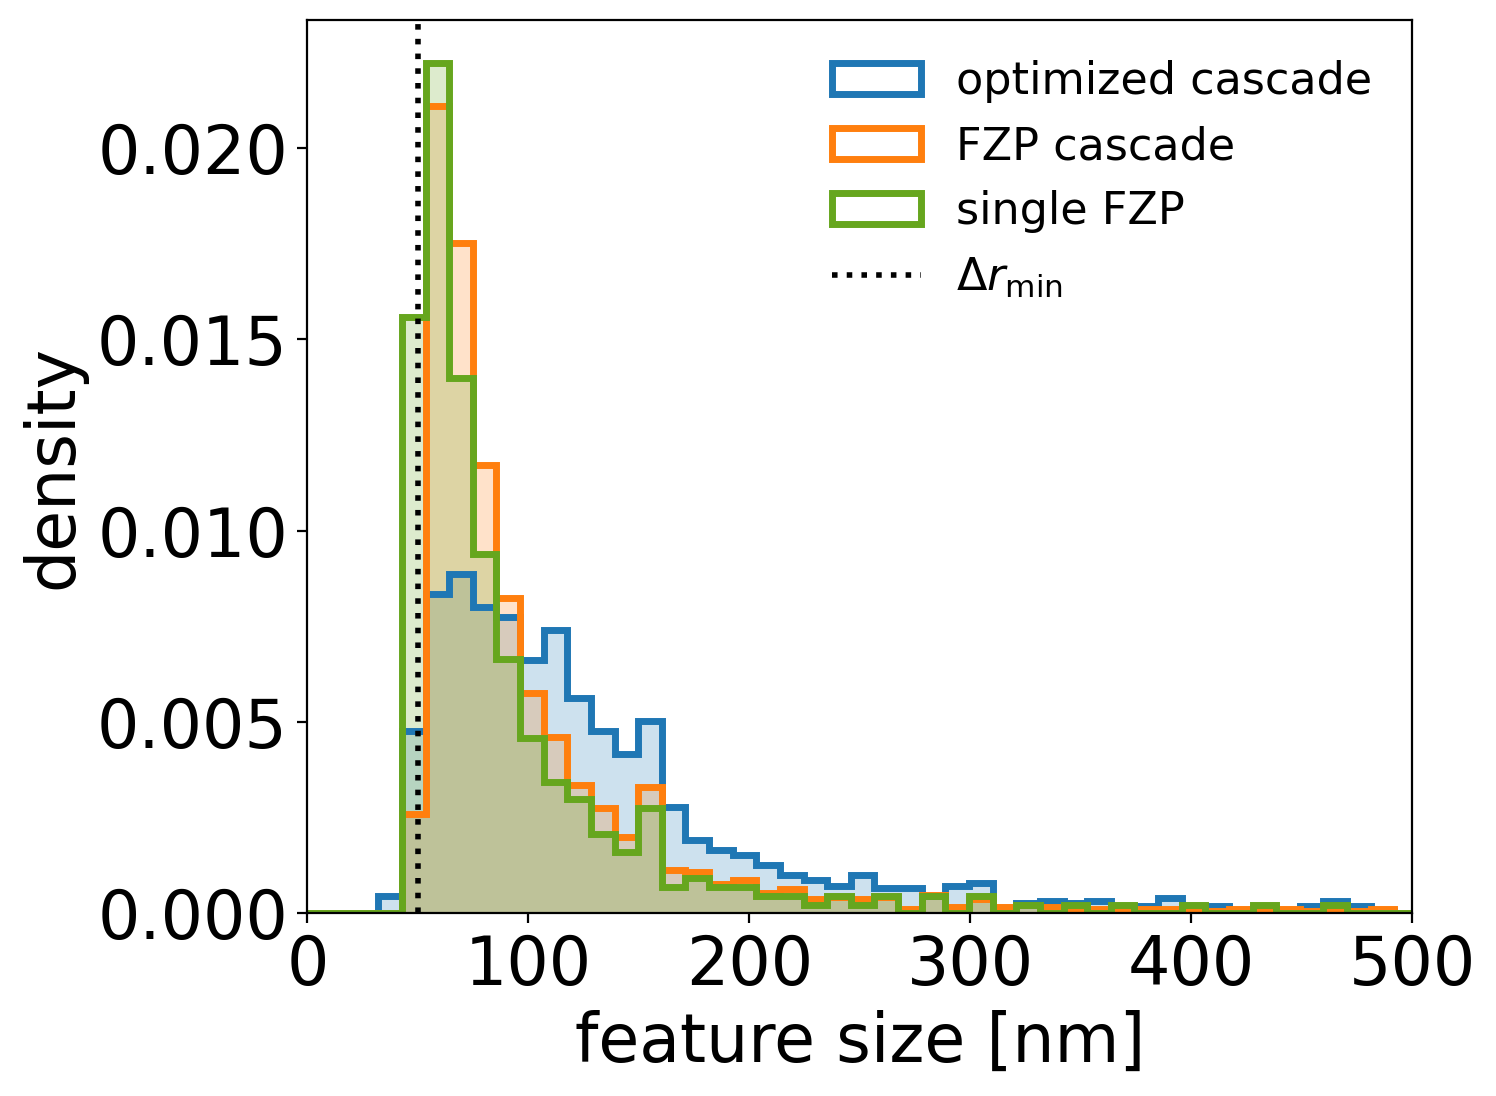

In [104]:
from src.util import get_feature_sizes

fzp_single = np.asarray(results["fzp_x"]).astype(float).reshape(-1)[:n_half]


def feature_sizes_nm(profiles: np.ndarray) -> np.ndarray:
    profiles = np.atleast_2d(np.asarray(profiles, dtype=int))
    sizes_px = np.concatenate([get_feature_sizes(p) for p in profiles])
    return sizes_px.astype(float) * dx * 1e9


opt_sizes = feature_sizes_nm(opt_profiles)
fzp_cascade_sizes = feature_sizes_nm(fzp_profiles)
fzp_sizes = feature_sizes_nm(fzp_single)
size_arrays = [opt_sizes, fzp_cascade_sizes, fzp_sizes]
mfs_nm = float(params["min_feature_size"]) * 1e9

print(f"{'optic':<22} {'N':>8} {'min [nm]':>10} {'median [nm]':>12} {'max [nm]':>10}")
for label, sizes in zip(labels, size_arrays):
    print(f"{label:<22} {sizes.size:8d} {sizes.min():10.1f} {np.median(sizes):12.1f} {sizes.max():10.1f}")

bin_max = max(float(s.max()) for s in size_arrays)
bins = np.linspace(0.0, bin_max, 160)

fig, ax = plt.subplots(figsize=(8, 6))
for sizes, label, color in zip(size_arrays, labels, colors):
    ax.hist(
        sizes,
        bins=bins,
        density=True,
        histtype="stepfilled",
        alpha=0.22,
        color=color,
        linewidth=0,
    )
    ax.hist(
        sizes,
        bins=bins,
        density=True,
        histtype="step",
        linewidth=2.5,
        color=color,
        label=label,
    )
ax.axvline(mfs_nm, color="k", linestyle=":", linewidth=2, label=r"$\Delta r_{\min}$")
ax.set_xlabel("feature size [nm]")
ax.set_ylabel("density")
ax.set_xlim(0, 500)
ax.legend(fontsize=16, frameon=False)
fig.tight_layout()
